In [1]:
import pandas as pd
import numpy as np
import os 
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sn

In [2]:
models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges').glob("*"))
models

[PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/.ipynb_checkpoints'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-15dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-18dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-5dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_0dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_range

In [3]:
models.remove(models[0])
len(models)

24

In [4]:
#list(models[0].rglob("*.csv"))

In [5]:
# Get csvs of results for each model 

csv_str = 'metrics.csv'
#models = [attn_models[0], ctrl_models[0]]

dfs = []
for model in models:
    # get test csvs
    results_csvs = model.rglob("*.csv")
    
    for csv in results_csvs:
#         print(csv)
        df = pd.read_csv(csv)
        #print(model)

        df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
        test_parts = str(model).split("/")[-1].split("_")
        #print(test_parts)
        df['model'] = test_parts[0]
#       print(test_parts)
        df['snr_condition'] = test_parts[1]
        
        if (test_parts[0] == "AttnTrackingControl"):
            df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
            df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]
        
        dfs.append(df)
        
#         if 'Test' in path.as_posix()
results = pd.concat(dfs, axis=0, ignore_index=True)
results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
results.drop('epoch', axis=1, inplace=True)
results

,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,version,model,snr_condition,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion
0,1.0,1.0,0,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
1,1.0,1.0,1,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
2,0.0,1.0,2,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
3,1.0,0.0,3,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
4,1.0,0.0,4,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
836027,1.0,0.0,16808,1,AttnTrackingControl,clean,1.0,NaN,0.0,NaN
836028,0.0,0.0,16809,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
836029,0.0,0.0,16810,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
836030,0.0,0.0,16811,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN


In [6]:
# !head -n 5 ../attn_cue_models/attn_check_snr_ranges/AttnTrackingControl_clean/version_1/metrics.csv

In [7]:
# filter for most recent results 
version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
filtered_results = results[results.version == version_maxes]
filtered_results

,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,version,model,snr_condition,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion
16813,NaN,NaN,0,1,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0
16814,NaN,NaN,1,1,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0
16815,NaN,NaN,2,1,AttnCNNConstrained,-10dB,0.0,1.0,1.0,0.0
16816,NaN,NaN,3,1,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0
16817,NaN,NaN,4,1,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
836027,1.0,0.0,16808,1,AttnTrackingControl,clean,1.0,NaN,0.0,NaN
836028,0.0,0.0,16809,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
836029,0.0,0.0,16810,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
836030,0.0,0.0,16811,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN


In [8]:
filtered_results['attended_accuracy'] = (filtered_results['ACC/test_fg_acc_step'] + filtered_results['ACC/test_bg_acc_step'])/2
filtered_results

<ipython-input-8-19783ec6e552>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['attended_accuracy'] = (filtered_results['ACC/test_fg_acc_step'] + filtered_results['ACC/test_bg_acc_step'])/2


,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,version,model,snr_condition,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion,attended_accuracy
16813,NaN,NaN,0,1,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0,NaN
16814,NaN,NaN,1,1,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0,NaN
16815,NaN,NaN,2,1,AttnCNNConstrained,-10dB,0.0,1.0,1.0,0.0,NaN
16816,NaN,NaN,3,1,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0,NaN
16817,NaN,NaN,4,1,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
836027,1.0,0.0,16808,1,AttnTrackingControl,clean,1.0,NaN,0.0,NaN,0.5
836028,0.0,0.0,16809,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN,0.0
836029,0.0,0.0,16810,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN,0.0
836030,0.0,0.0,16811,1,AttnTrackingControl,clean,0.0,NaN,0.0,NaN,0.0


In [9]:
filtered_results['model'].replace('AttnCNN','unconstrained slope',inplace=True)
filtered_results['model'].replace('AttnCNNConstrained','constrained slope',inplace=True)
filtered_results['model'].replace('AttnTrackingControl','control',inplace=True)



<ipython-input-9-742fe34e09ee>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['model'].replace('AttnCNN','unconstrained slope',inplace=True)
<ipython-input-9-742fe34e09ee>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['model'].replace('AttnCNNConstrained','constrained slope',inplace=True)
<ipython-input-9-742fe34e09ee>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['model'].repl

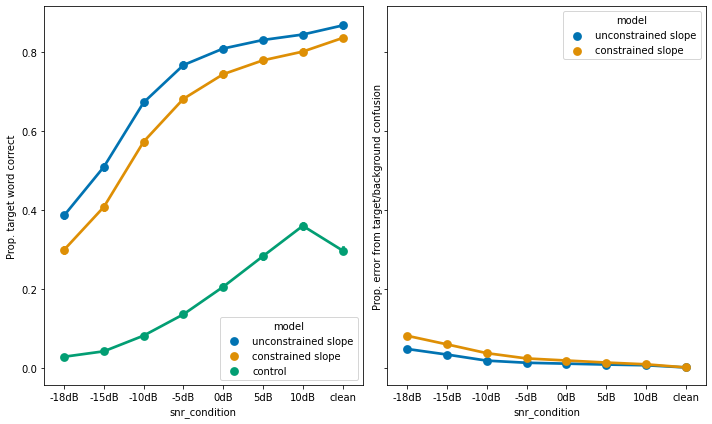

In [10]:
fig, axs = plt.subplots(1,2, sharey=True, figsize=(10,6))
axs = axs.ravel()

g = sn.pointplot(
    data=filtered_results, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', hue_order=['unconstrained slope', 'constrained slope', "control"],
    ci=95, seed=1, ax=axs[0],
    palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
)


g1 = sn.pointplot(
    data=filtered_results, x='snr_condition',y='fg_confusion',
    hue='model', hue_order=['unconstrained slope', 'constrained slope'],
    ci=95, seed=1, ax=axs[1],
    palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
)

axs[0].set_ylabel("Prop. target word correct")
axs[1].set_ylabel("Prop. error from target/background confusion")

plt.tight_layout()

#axs.set(xlabel="snr range", ylabel='proportion correct', title='snr check')
#g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

In [160]:
check_weirdness_df = filtered_results[filtered_results['model'] == "AttnCNNConstrained"]
check_weirdness_df_0dB = check_weirdness_df[check_weirdness_df['snr_condition'] == '0dB']
check_weirdness_df_5dB = check_weirdness_df[check_weirdness_df['snr_condition'] == '5dB']

In [ ]:
fig, axs = plt.subplots (1, 2, figsize=(15, 6))


g = sn.barplot(
    data=rms_results, x='snr_condition',y='ACC/test_fg_acc', hue='model',
    ci=None, seed=1, ax=axs[0]
)
axs[0].set(xlabel="snr range", ylabel='proportion correct', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=rms_results, x='snr_condition',y='ACC/test_bg_acc', hue='model',
    ci=None, seed=1, ax=axs[1]
)
axs[1].set(xlabel="snr range", ylabel='proportion correct', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

In [ ]:
fig, axs = plt.subplots (1, 2, figsize=(15, 6))


g = sn.barplot(
    data=rms_results, x='snr_condition',y='fg_confusion', hue='model',
    ci=None, seed=1, ax=axs[0]
)
axs[0].set(xlabel="snr range", ylabel='proportion confused', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=rms_results, x='snr_condition',y='bg_confusion', hue='model',
    ci=None, seed=1, ax=axs[1]
)
axs[1].set(xlabel="snr range", ylabel='proportion confused', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

In [ ]:
#get the subset of datapoints where the model fails
fg_confusion_results = rms_results[rms_results['ACC/test_fg_acc'] == 0]
bg_confusion_results = rms_results[rms_results['ACC/test_bg_acc'] == 0]
both_confusion_results = fg_confusion_results[fg_confusion_results['ACC/test_bg_acc'] == 0]

In [ ]:
fig, axs = plt.subplots (1, 2, figsize=(15, 6))


g = sn.barplot(
    data=fg_confusion_results, x='snr_condition',y='fg_confusion', hue='model',
    ci=None, seed=1, ax=axs[0]
)
axs[0].set(xlabel="snr range", ylabel='proportion confused', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=bg_confusion_results, x='snr_condition',y='bg_confusion', hue='model',
    ci=None, seed=1, ax=axs[1]
)
axs[1].set(xlabel="snr range", ylabel='proportion confused', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

## Combining the Results

In [ ]:
filtered_results.rename(columns={"ACC/test_fg_acc_step": "ACC/test_fg_acc", "ACC/test_bg_acc_step": "ACC/test_bg_acc" }, inplace=True)
filtered_results
combined_results = pd.concat([rms_results, filtered_results], axis=0, ignore_index=True)
combined_results['attended accuracy'] = (combined_results['ACC/test_fg_acc'] + combined_results['ACC/test_bg_acc'])/2
combined_results

In [ ]:
test = combined_results.groupby(['model', 'snr_condition']).mean()
test

In [ ]:
fig, axs = plt.subplots (1, 3, figsize=(15, 6))


g = sn.barplot(
    data=combined_results, x='snr_condition',y='ACC/test_fg_acc', hue='model',
    ci=None, seed=1, ax=axs[0], palette='colorblind'
)
axs[0].set(xlabel="snr range", ylabel='proportion correct', title='attend foreground')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

h = sn.barplot(
    data=combined_results, x='snr_condition',y='ACC/test_bg_acc', hue='model',
    ci=None, seed=1, ax=axs[1], palette='colorblind'
)
axs[1].set(xlabel="snr range", ylabel='proportion correct', title='attend background')
h.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

i = sn.barplot(
    data=combined_results, x='snr_condition',y='attended accuracy', hue='model',
    ci=None, seed=1, ax=axs[2], palette='colorblind'
)
axs[2].set(xlabel="snr range", ylabel='proportion correct', title='cued accuracy')
i.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

plt.tight_layout()

In [ ]:
#snr condition, then check if the lower db word was guessed
#neutral condition, check if it gets either

In [ ]:
control_confusion_results = combined_results[combined_results['model'] == "AttnTrackingControl"]
print(control_confusion_results.shape)
control_confusion_results['ctrl_confusion'] = '0'


control_confusion_results.loc[control_confusion_results['snr_condition']=='high', 'ctrl_confusion'] = control_confusion_results['ACC/test_bg_acc']
control_confusion_results.loc[control_confusion_results['snr_condition']=='low', 'ctrl_confusion'] = control_confusion_results['ACC/test_fg_acc']
control_confusion_results.loc[control_confusion_results['snr_condition']=='neutral', 'ctrl_confusion'] = control_confusion_results['ACC/test_fg_acc']

#if it got either word right, ie an attended accuracy of 0.5 or 1, then
#set the control confusion to 1 because it got at least 1 right
control_confusion_results.loc[control_confusion_results['ctrl_confusion'] > 0.1, 'ctrl_confusion'] = 1.0

# control_confusion_results
#print(control_confusion_results[control_confusion_results['snr_condition'] == 'high'])
subset = control_confusion_results[pd.isna(control_confusion_results['ACC/test_fg_acc'])]
#subset
#subset.filter()

control_confusion_results.drop([67248, 84061, 100874], axis=0, inplace=True)
#control_confusion_results

control_confusion_results['control_listening_condition'] = "low"
louder_word_rec = control_confusion_results.copy(deep=True)
louder_word_rec['control_listening_condition'] = "high"

louder_word_rec.loc[louder_word_rec['snr_condition']=='high', 'ctrl_confusion'] = louder_word_rec['ACC/test_fg_acc']
louder_word_rec.loc[louder_word_rec['snr_condition']=='low', 'ctrl_confusion'] = louder_word_rec['ACC/test_bg_acc']
louder_word_rec.loc[louder_word_rec['snr_condition']=='neutral', 'ctrl_confusion'] = louder_word_rec['ACC/test_bg_acc']

#if it got either word right, ie an attended accuracy of 0.5 or 1, then
#set the control confusion to 1 because it got at least 1 right
louder_word_rec.loc[louder_word_rec['ctrl_confusion'] > 0.1, 'ctrl_confusion'] = 1.0

combined_confusion_results = pd.concat([control_confusion_results, louder_word_rec], axis=0)
combined_confusion_results

In [ ]:
fig, axs = plt.subplots (1, 1, figsize=(15, 6))

g = sn.barplot(
    data=combined_confusion_results, x='snr_condition',y='ctrl_confusion', hue='control_listening_condition',
    ci=None, seed=1, ax=axs, palette='colorblind'
)
axs.set(xlabel="snr range", ylabel='proportion confused', title='control confusion')
g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])


plt.tight_layout()